In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
original_df=pd.read_csv("test_df_with_usd_login.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.shape

(4462, 15)

In [5]:
df.columns

Index(['company_size', 'is_premium', 'subscription_status',
       'jobma_catcher_status', 'sub_users', 'wallet_amount', 'is_unlimited',
       'plan_type', 'subscription_count', 'invitations',
       'pre_recorded_kit_counts', 'number_of_jobs_posted',
       'pre_rec_interview_taken', 'subscription_amount_usd',
       'days_since_login'],
      dtype='object')

In [6]:
df.isna().sum()

company_size               0
is_premium                 0
subscription_status        0
jobma_catcher_status       0
sub_users                  0
wallet_amount              0
is_unlimited               0
plan_type                  0
subscription_count         0
invitations                0
pre_recorded_kit_counts    0
number_of_jobs_posted      0
pre_rec_interview_taken    0
subscription_amount_usd    0
days_since_login           0
dtype: int64

In [56]:
df.nunique()

company_size                 5
is_premium                   2
subscription_status          2
jobma_catcher_status         2
sub_users                   19
wallet_amount              179
is_unlimited                 2
plan_type                    2
subscription_count          34
invitations                126
pre_recorded_kit_counts     57
number_of_jobs_posted       51
pre_rec_interview_taken     89
subscription_amount_usd    707
days_since_login           774
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4462 non-null   object 
 1   is_premium               4462 non-null   int64  
 2   subscription_status      4462 non-null   int64  
 3   jobma_catcher_status     4462 non-null   int64  
 4   sub_users                4462 non-null   int64  
 5   wallet_amount            4462 non-null   float64
 6   is_unlimited             4462 non-null   int64  
 7   plan_type                4462 non-null   int64  
 8   subscription_count       4462 non-null   int64  
 9   invitations              4462 non-null   int64  
 10  pre_recorded_kit_counts  4462 non-null   int64  
 11  number_of_jobs_posted    4462 non-null   int64  
 12  pre_rec_interview_taken  4462 non-null   int64  
 13  subscription_amount_usd  4462 non-null   float64
 14  days_since_login        

In [8]:
df

,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login
0,1-25,0,1,1,1,66666.0,1,0,1,4,2,1,1,176.5,376
1,1-25,0,1,1,1,66666.0,1,0,1,4,2,1,1,176.5,418
2,26-100,0,2,1,0,60.0,0,1,1,0,0,0,0,0.6,438
3,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,1.4,438
4,26-100,0,1,1,0,50.0,0,1,3,0,0,1,0,178.8,438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,1-25,0,1,1,0,35.0,0,0,1,3,1,2,3,1.2,329
4458,1-25,0,1,1,0,147.0,0,0,1,3,3,5,1,0.0,328
4459,26-100,0,1,1,0,50.0,0,0,1,0,0,0,0,1.2,328
4460,1-25,0,1,1,0,49.0,0,0,1,2,2,2,1,0.0,326


In [9]:
binary_columns = ['is_premium',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]

categorical_columns = ['company_size']
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken',
                   'days_since_login']

ordinal_columns =['subscription_amount_usd']

In [10]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [11]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [12]:
# pipeline

In [13]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4462, 19])

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [15]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20
batch_size = 16

In [16]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/20, Loss: 0.0518
Epoch 4/20, Loss: 0.0491
Epoch 6/20, Loss: 0.0491
Epoch 8/20, Loss: 0.0486
Epoch 10/20, Loss: 0.0370
Epoch 12/20, Loss: 0.0392
Epoch 14/20, Loss: 0.0307
Epoch 16/20, Loss: 0.0289
Epoch 18/20, Loss: 0.0334
Epoch 20/20, Loss: 0.0425


In [17]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4462, 32)

In [18]:
type(embeddings_np), embeddings.shape

(numpy.ndarray, torch.Size([4462, 32]))

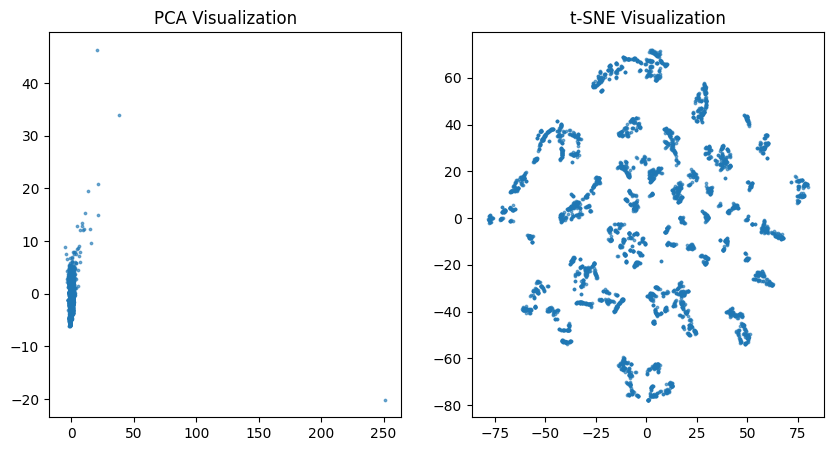

In [19]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()

# Visualisation

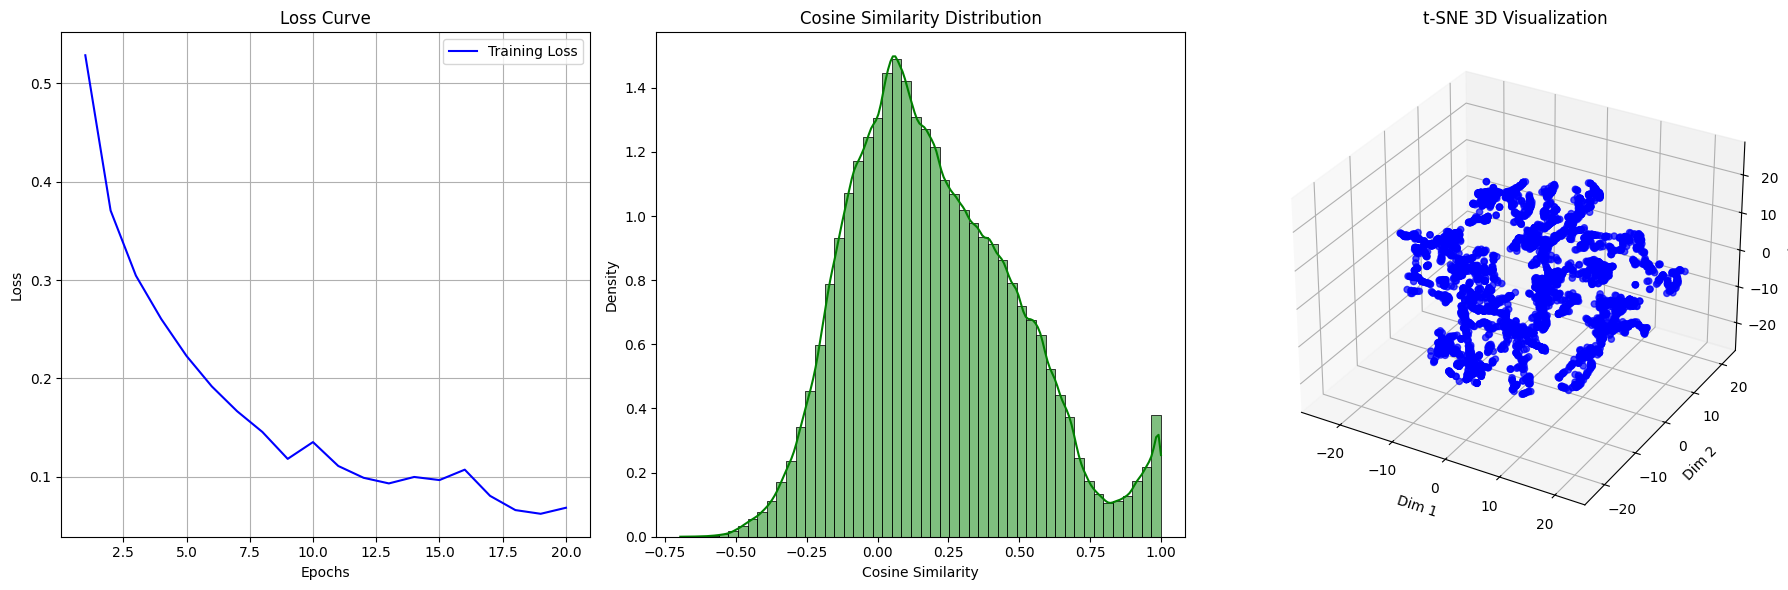

In [31]:
#Loss Curve
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Loss per epochs', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

#Cosine Similarity Histogram
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

#t-SNE in 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c='blue', alpha=0.7)
ax3.set_title('t-SNE 3D Visualization')
ax3.set_xlabel('Dim 1')
ax3.set_ylabel('Dim 2')
ax3.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

# Similarity

In [21]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
        
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [22]:
df.max()

company_size               More than 1000
is_premium                              1
subscription_status                     2
jobma_catcher_status                    1
sub_users                              40
wallet_amount                   4995968.0
is_unlimited                            1
plan_type                               1
subscription_count                    116
invitations                         50046
pre_recorded_kit_counts               292
number_of_jobs_posted                 189
pre_rec_interview_taken               635
subscription_amount_usd         1398501.6
days_since_login                     1794
dtype: object

In [120]:
sample_dict={'company_size': '101-500',
             'is_premium': 0,
             'subscription_status': 2,
             'jobma_catcher_status': 1,
             'sub_users': 0,
             'wallet_amount': 50.0,
             'is_unlimited': 1,
             'plan_type': 0,
             'subscription_count': 1,
             'invitations': 0,
             'pre_recorded_kit_counts': 2,
             'number_of_jobs_posted': 2,
             'pre_rec_interview_taken': 1,
             'subscription_amount_usd': 208.2,
            'days_since_login':376 }

In [121]:
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,7496,101-500,0,2,1,0,60.0,1,0,1,0,0,0,0,352.9,1048,0.925280
1,7504,101-500,0,2,1,0,60.0,1,0,2,1,1,1,0,941.2,1044,0.924497
2,9037,101-500,0,1,1,0,60.0,1,0,1,2,1,1,2,117.6,796,0.921027
3,7274,101-500,0,2,1,0,60.0,1,0,1,0,0,0,0,235.3,1068,0.920502
4,8983,101-500,0,1,1,0,60.0,1,0,1,0,0,0,0,117.6,631,0.919318


In [127]:
sample_dict2 = { 'company_size': '101-500',
                 'is_premium': 0,
                 'subscription_status': 2,
                 'jobma_catcher_status': 1,
                 'sub_users': 0,
                 'wallet_amount': 60,
                 'is_unlimited': 0,
                 'plan_type': 0,
                 'subscription_count': 8,
                 'invitations': 25,
                 'pre_recorded_kit_counts': 3,
                 'number_of_jobs_posted': 5,
                 'pre_rec_interview_taken': 0,
                 'subscription_amount_usd': 118.8,
                 'days_since_login': 1086}

In [128]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,7500,101-500,0,1,1,1,3735.0,0,0,9,0,1,2,0,171.4,1035,0.897582
1,8135,101-500,0,1,1,0,60.0,0,0,7,0,0,0,0,71.4,987,0.890113
2,7186,101-500,0,1,1,0,60.0,0,0,5,0,0,0,0,73.0,1070,0.886401
3,6916,101-500,0,2,1,1,60.0,0,0,5,0,0,0,0,64.8,1080,0.867262
4,7321,101-500,0,1,1,1,60.0,0,0,5,0,0,0,0,63.7,1064,0.865817


In [131]:
sample_dict3 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 66,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations': 5,
                'pre_recorded_kit_counts':5 ,
                'number_of_jobs_posted': 5,
                'pre_rec_interview_taken': 10,
                'subscription_amount_usd': 118.8,
                'days_since_login':1000}

In [132]:
recommend_from_sample_dict(sample_dict3, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,7458,26-100,0,2,1,0,60.0,1,0,4,0,0,0,0,941.2,1051,0.865375
1,7364,26-100,0,1,1,1,60.0,1,0,4,0,0,0,0,470.4,1063,0.853479
2,6258,26-100,0,1,1,0,60.0,1,0,4,0,0,0,0,235.2,1122,0.853195
3,7030,26-100,0,1,1,0,60.0,1,0,3,0,0,0,0,352.8,1076,0.852911
4,7087,26-100,0,1,1,0,60.0,1,0,3,0,0,0,0,352.8,1072,0.852866


In [133]:
sample_dict4 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 3,
                'invitations': 4,
                'pre_recorded_kit_counts': 1,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_amount_usd': 118.5,
                'days_since_login': 1568}

In [30]:
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,4878,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,1176.5,1489,0.881509
1,4880,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,1176.5,1489,0.881509
2,4839,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,176.5,1491,0.861142
3,4891,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,117.6,1489,0.844186
4,7026,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,1058.8,1076,0.840466


In [134]:
sample_dict5 = {'company_size': '1-25',
                'is_premium': 0,
                'subscription_status': 1,
                'jobma_catcher_status': 1,
                'sub_users': 1,
                'wallet_amount': 66.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 1,
                'invitations': 4,
                'pre_recorded_kit_counts': 2,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 1,
                'subscription_amount_usd': 176.5,
                'days_since_login': 418
               }

In [36]:
recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,6009,1-25,0,2,1,1,60.0,1,0,1,4,1,1,6,117.6,1190,0.941844
1,7772,1-25,0,1,1,0,60.0,1,0,3,3,2,0,3,352.8,971,0.935592
2,9042,1-25,0,1,1,1,60.0,1,0,1,2,1,1,1,117.6,804,0.934757
3,7872,1-25,0,1,1,0,60.0,1,0,2,0,0,0,0,235.2,1026,0.928057
4,7336,1-25,0,2,1,0,60.0,1,0,2,0,0,0,0,235.2,1064,0.926037


In [91]:
sample_dict6 = {'company_size': '500-1000',
                'is_premium': 1,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 11,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 2,
                'invitations': 96,
                'pre_recorded_kit_counts': 19,
                'number_of_jobs_posted': 14,
                'pre_rec_interview_taken': 54,
                'subscription_amount_usd': 694.2,
                'days_since_login': 1090,
               }

In [92]:
recommend_from_sample_dict(sample_dict6, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,6227,500-1000,1,2,1,11,60.0,0,1,2,96,19,14,54,694.2,1090,0.921772
1,8334,500-1000,1,1,1,13,60.0,0,0,4,0,0,0,0,55.4,944,0.875262
2,6017,500-1000,1,1,1,10,1860.0,0,0,11,15,6,9,5,56.7,466,0.838321
3,8501,26-100,1,1,1,14,1860.0,0,0,2,57,66,6,27,23.0,610,0.795391
4,8329,1-25,0,2,1,9,60.0,0,1,1,184,11,19,74,294.1,873,0.787126


In [80]:
sample_dict7 = {'company_size': '101-500',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations':24,
                'pre_recorded_kit_counts': 0,
                'number_of_jobs_posted': 0,
                'pre_rec_interview_taken': 0,
                'subscription_amount_usd': 1.4,
                'days_since_login': 400,
               }

In [82]:
recommend_from_sample_dict(sample_dict7, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,9671,101-500,0,1,1,0,150.0,0,1,1,0,0,0,0,2.9,644,0.882696
1,2937,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,1.4,438,0.868857
2,6947,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,0.7,1078,0.868015
3,5280,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,2.8,1446,0.859254
4,5145,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,2.8,1456,0.857878
